# Lab 10: Visualization for Fairness and Model Evaluation

In this lab, we work through common plot types and then complete a set of lab tasks at the end.

We will practice the main plot types you should know how to read and create:
- line plots
- bar plots
- histograms
- scatter plots
- calibration-by-bin plots

We will use **two datasets**:
1. a monthly bail-decision dataset for **time-based plots**
2. a prediction dataset for **fairness and calibration plots**

The core pattern we will reuse is:

```python
sns.<plot_type>(data=df, x='some_column', y='some_other_column', hue='group_if_needed')
```

Then we use `matplotlib` to add titles, labels, legends, and reference lines.


In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

sns.set_theme(style='whitegrid');
sns.set(rc={'figure.figsize': (10, 6)});


## Part 1. Time-Based Plots

This first dataset comes from a different class, but the plotting logic is the same.

It is a county-month dataset on bail decisions in Maryland. The key columns are:
- `months_from_reform`: time, where `0` is the reform month
- `pct_ror`: percent released on recognizance
- `pct_felony`: percent felony hearings
- `county`: county name


In [13]:
bail = pd.read_csv(
    'https://raw.githubusercontent.com/zjelveh/zjelveh.github.io/master/files/ccjs418e_fall2025/bail_decisions_monthly.csv'
)

bail = bail[bail['county'] != 'STATEWIDE'].copy()
bail['year_month'] = pd.to_datetime(bail['year_month_str'])

bail.head()

,county,year,month,year_month_str,months_from_reform,n_total_hearings,n_felony_hearings,n_ror,n_hdob,n_hwob,pct_ror,pct_hdob,pct_hwob,pct_felony,year_month
0,Allegany,2016,1,2016-01,-10,71,10,21,36,14,29.577465,50.704225,19.718310,14.084507,2016-01-01
1,Allegany,2016,2,2016-02,-9,91,14,21,54,16,23.076923,59.340659,17.582418,15.384615,2016-02-01
2,Allegany,2016,3,2016-03,-8,72,5,20,37,15,27.777778,51.388889,20.833333,6.944444,2016-03-01
3,Allegany,2016,4,2016-04,-7,85,11,26,47,12,30.588235,55.294118,14.117647,12.941176,2016-04-01
4,Allegany,2016,5,2016-05,-6,96,8,27,52,17,28.125000,54.166667,17.708333,8.333333,2016-05-01


### Choose one county for the time-series examples

We will use **Baltimore City** because it is present in the dataset.

This is an important debugging lesson: if your filtered DataFrame is empty, your plot may look broken or the axes may collapse in strange ways.


In [14]:
county_df = bail[bail['county'] == 'Baltimore City'].copy()
county_df = county_df.sort_values('months_from_reform')

county_df[['county', 'months_from_reform', 'pct_ror']].head()

,county,months_from_reform,pct_ror
108,Baltimore City,-10,40.853081
109,Baltimore City,-9,43.394407
110,Baltimore City,-8,42.562339
111,Baltimore City,-7,43.494777
112,Baltimore City,-6,41.954023


### Line plot: one county over time

**Why this plot type?**
- Use a line plot when the x-axis is ordered time.
- It is good for showing the shape of a trend.

**Key parameters**
- `data=county_df`: which DataFrame to use
- `x='months_from_reform'`: the time variable
- `y='pct_ror'`: the outcome we want to track
- `marker='o'`: adds visible points on top of the line

**Useful variants**
- remove `marker='o'` if you want a cleaner line
- keep `marker='o'` if you want the observed points to stay visible
- add `hue='county'` if you want multiple counties in one figure
- use `plt.axvline(...)` to mark an intervention or policy change


<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='months_from_reform', ylabel='pct_ror'>

Text(0.5, 1.0, 'ROR Rate Over Time: Baltimore City')

Text(0.5, 0, 'Months from Reform')

Text(0, 0.5, 'Percent Released on Recognizance')

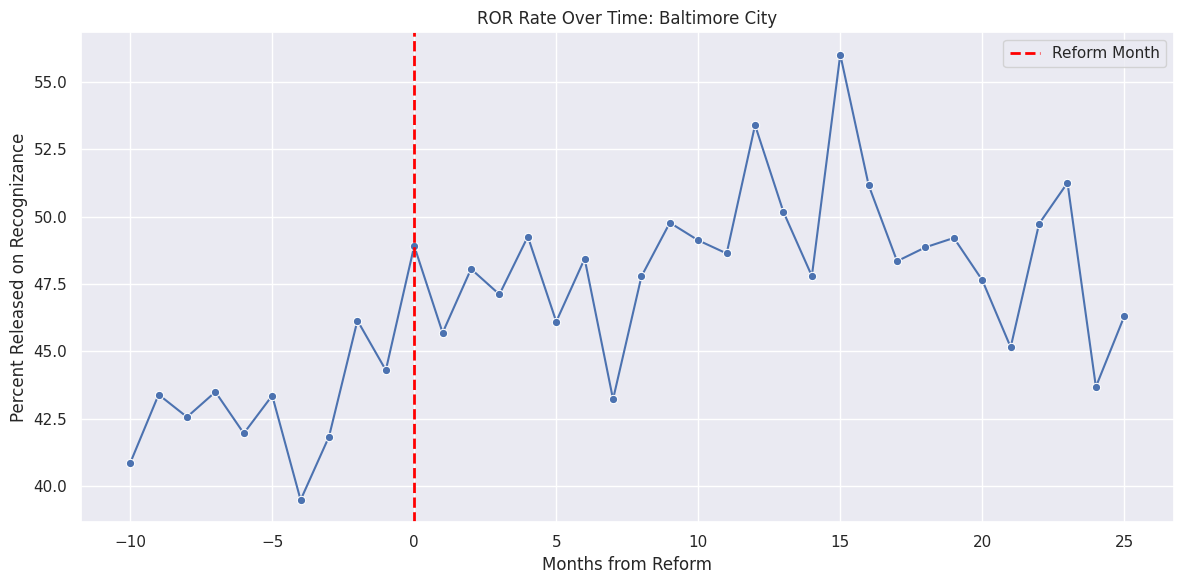

In [15]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=county_df, x='months_from_reform', y='pct_ror', marker='o');
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Reform Month');
plt.title("ROR Rate Over Time: Baltimore City");
plt.xlabel('Months from Reform');
plt.ylabel('Percent Released on Recognizance');
plt.legend();
plt.tight_layout();
plt.show()

### Bar plot: before versus after by county

**Why this plot type?**
- Use a bar plot when the x-axis is categorical.
- Here we compare counties and split each county into `Before` and `After`. We will sort counties by their average `Before` ROR rate so the ordering is easier to read.

**Key parameters**
- `x='county'`: each county gets a bar position
- `y='pct_ror'`: height of the bar
- `hue='period'`: split each county into `Before` and `After` bars

**Useful variants**
- switch `x='period'` and `hue='county'` to tell a different comparison story
- rotate x-axis labels when category names are long
- sort categories before plotting if you want a more interpretable ordering
- subset to a few counties if the chart gets cluttered


<Figure size 1400x600 with 0 Axes>

<Axes: xlabel='county', ylabel='pct_ror'>

Text(0.5, 1.0, 'Average ROR Rate by County: Before vs After Reform')

Text(0.5, 0, 'County')

Text(0, 0.5, 'Average ROR Rate')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, 'Somerset'),
  Text(1, 0, 'Howard'),
  Text(2, 0, 'Dorchester'),
  Text(3, 0, 'Cecil'),
  Text(4, 0, 'Montgomery'),
  Text(5, 0, 'Kent'),
  Text(6, 0, 'Queen Anne'),
  Text(7, 0, 'Baltimore'),
  Text(8, 0, 'Calvert'),
  Text(9, 0, 'Wicomico'),
  Text(10, 0, 'Garrett'),
  Text(11, 0, 'Allegany'),
  Text(12, 0, 'Carroll'),
  Text(13, 0, 'Caroline'),
  Text(14, 0, 'Talbot'),
  Text(15, 0, 'Washington'),
  Text(16, 0, 'Prince George'),
  Text(17, 0, 'Saint Mary'),
  Text(18, 0, 'Baltimore City'),
  Text(19, 0, 'Frederick'),
  Text(20, 0, 'Charles'),
  Text(21, 0, 'Harford'),
  Text(22, 0, 'Worcester'),
  Text(23, 0, 'Anne Arundel')])

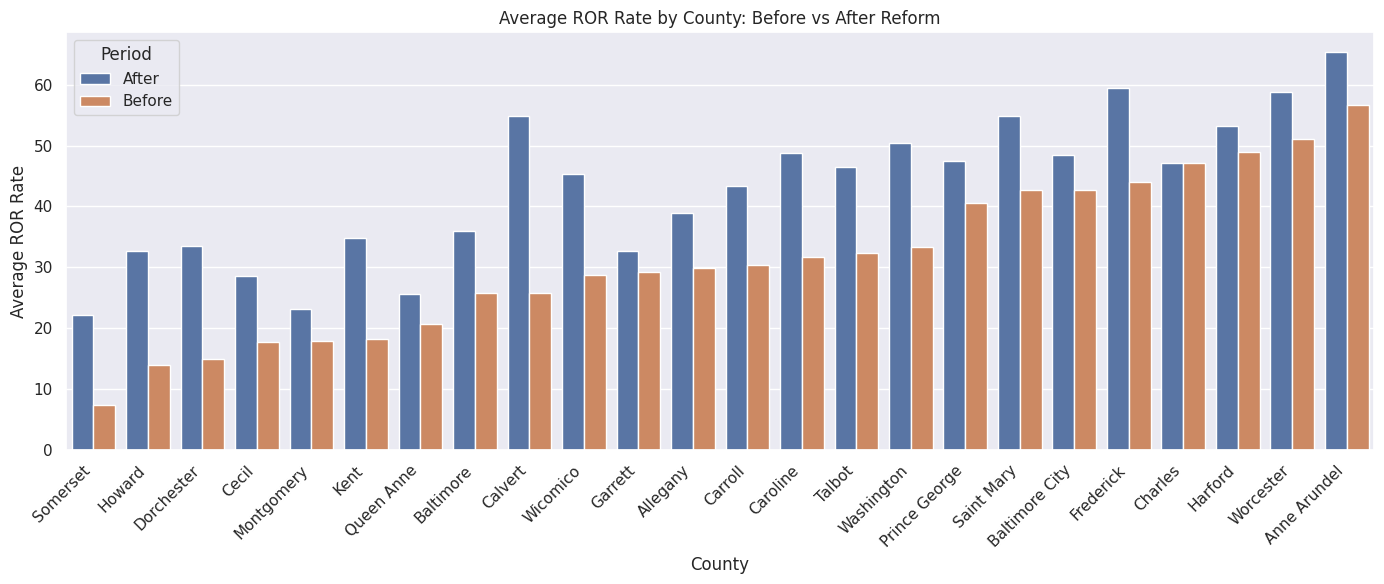

In [16]:
bail['period'] = bail['months_from_reform'].apply(lambda x: 'Before' if x < 0 else 'After')
county_period_avg = bail.groupby(['county', 'period'])['pct_ror'].mean().reset_index()

before_order = (
    county_period_avg[county_period_avg['period'] == 'Before']
    .sort_values('pct_ror')['county']
    .tolist()
)

plt.figure(figsize=(14, 6))
sns.barplot(data=county_period_avg, x='county', y='pct_ror', hue='period', order=before_order);
plt.title('Average ROR Rate by County: Before vs After Reform');
plt.xlabel('County');
plt.ylabel('Average ROR Rate');
plt.xticks(rotation=45, ha='right');
plt.legend(title='Period');
plt.tight_layout();
plt.show()

### Histogram: distribution of one variable

**Why this plot type?**
- A histogram is for the distribution of a single variable.
- It helps you see concentration, spread, skew, and outliers.

**Key parameters**
- `x='pct_ror'`: the one variable whose distribution we want
- `bins=20`: how many bars to use
- `kde=True`: add a smooth density curve

**Useful variants**
- smaller `bins` = smoother, simpler picture
- larger `bins` = more detail, but more noise
- `hue='group'` can compare distributions across groups if overlap is manageable


<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='pct_ror', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of ROR Rates Across County-Months')

Text(0.5, 0, 'Percent Released on Recognizance')

Text(0, 0.5, 'Count of County-Months')

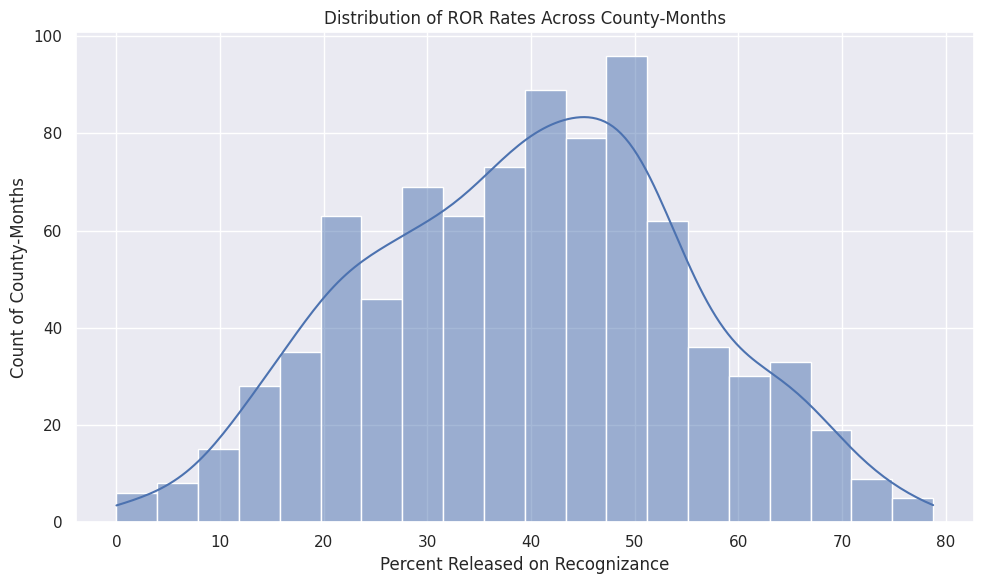

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(data=bail, x='pct_ror', bins=20, kde=True);
plt.title('Distribution of ROR Rates Across County-Months');
plt.xlabel('Percent Released on Recognizance');
plt.ylabel('Count of County-Months');
plt.tight_layout();
plt.show()

### Scatter plot: relationship between two variables

**Why this plot type?**
- Use a scatter plot when both axes are numeric.
- It helps you see association, clustering, and outliers.

**Key parameters**
- `x='pct_felony'`: numeric variable on the x-axis
- `y='pct_ror'`: numeric variable on the y-axis
- `alpha=0.5`: make points partly transparent so overlap is easier to see
- `s=50`: point size

**Useful variants**
- add `hue='period'` or another group variable to compare groups
- reduce `alpha` if many points overlap
- increase or decrease `s` to make points easier to see


<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='pct_felony', ylabel='pct_ror'>

Text(0.5, 1.0, 'Felony Rate vs ROR Rate')

Text(0.5, 0, 'Percent Felony Hearings')

Text(0, 0.5, 'Percent Released on Recognizance')

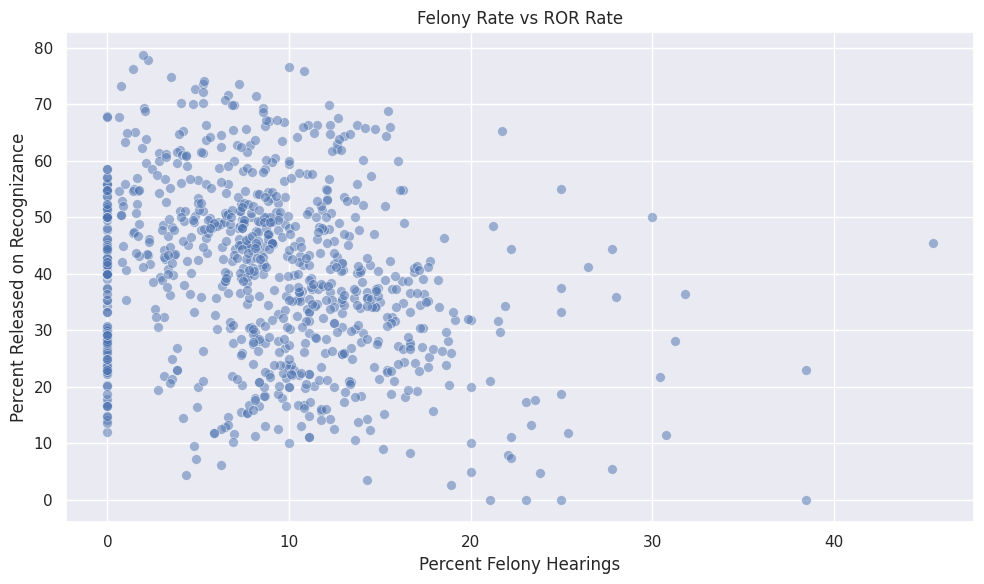

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=bail, x='pct_felony', y='pct_ror', alpha=0.5, s=50);
plt.title('Felony Rate vs ROR Rate');
plt.xlabel('Percent Felony Hearings');
plt.ylabel('Percent Released on Recognizance');
plt.tight_layout();
plt.show()

### Regplot: scatter plot with a fitted trend line

**Why this plot type?**
- `regplot` is useful when you want a quick visual summary of the trend.
- It combines a scatter plot with a fitted line.

**Key parameters**
- `scatter_kws={...}`: settings for the points
- `line_kws={...}`: settings for the fitted line

**Useful variants**
- lower point alpha if the scatter is dense
- change line color if you want the fitted line to stand out
- use this when the relationship is the main story, not each individual point


In [21]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=bail,
    x='pct_felony',
    y='pct_ror',
    scatter_kws={'alpha': 0.3, 's': 30},
    line_kws={'color': 'red'}
)
plt.title('Felony Rate vs ROR Rate (with fitted line)');
plt.xlabel('Percent Felony Hearings');
plt.ylabel('Percent Released on Recognizance');
plt.tight_layout();
plt.show()

SyntaxError: invalid syntax (1414699929.py, line 2)

## Part 2. Fairness and Model-Evaluation Plots

Now we switch to prediction data that are closer to this class.

Key columns are:
- `prediction_felony`: predicted probability for felony rearrest
- `y_felony`: actual felony rearrest outcome
- `prediction_nonfelony`: predicted probability for nonfelony rearrest
- `y_nonfelony`: actual nonfelony rearrest outcome
- `sex`, `race`: group variables


In [ ]:
universe = pd.read_csv(
    'https://www.dropbox.com/scl/fi/a2tpqpvkdc8n6advvkpt7/universe_lab9.csv?rlkey=839vsc25njgfftzakr34w2070&dl=1'
)

universe.head()

### Histogram of predicted probabilities

**Why this plot type?**
- This helps you see how the model is using the probability scale.
- Are predictions clustered near 0? Spread out? Piled up in the middle?

**Useful variants**
- try different values of `bins`
- try adding `hue='sex'` or `hue='race'` if you want group comparisons


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=universe, x='prediction_felony', bins=20, kde=True);
plt.title('Distribution of Predicted Probabilities: Felony Rearrest');
plt.xlabel('Predicted Probability');
plt.ylabel('Count');
plt.tight_layout();
plt.show()

### Bar plot of actual rates by group

**Why this plot type?**
- Before comparing model predictions by group, it helps to look at the actual outcome rate by group.
- This is a simple grouped-comparison plot.

**Useful variants**
- switch from `sex` to `race`
- compare actual rates and average predicted probabilities in separate plots


In [ ]:
sex_rates = universe.groupby('sex')['y_felony'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=sex_rates, x='sex', y='y_felony');
plt.title('Actual Felony Rearrest Rate by Sex');
plt.xlabel('Sex');
plt.ylabel('Average Outcome (Share with y=1)');
plt.tight_layout();
plt.show()

### Scatter plot comparing two model outputs

**Why this plot type?**
- Here we compare two numeric predictions for the same observations.
- This lets us see whether the two prediction tasks move together and whether groups cluster differently.

**Useful variants**
- change `hue='sex'` to `hue='race'`
- reduce `alpha` if the plot gets crowded
- change `s` to make points smaller or larger


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=universe,
    x='prediction_felony',
    y='prediction_nonfelony',
    hue='sex',
    alpha=0.4,
    s=35
)
plt.title('Felony vs Nonfelony Predicted Probabilities');
plt.xlabel('Prediction for Felony Rearrest');
plt.ylabel('Prediction for Nonfelony Rearrest');
plt.tight_layout();
plt.show()

## Part 3. Calibration by Bin

Calibration asks whether predicted probabilities match observed outcome rates.

A common workflow is:
1. divide predictions into bins
2. compute the average predicted probability in each bin
3. compute the actual outcome rate in each bin
4. compare the two

We can do this with `calibration_curve`.


In [ ]:
def calibration_plot(y_true, y_prob, n_bins=10, label='Model'):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='uniform')
    plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
    plt.plot(prob_pred, prob_true, marker='o', label=label)
    plt.xlabel('Average Predicted Probability in Bin')
    plt.ylabel('Observed Outcome Rate in Bin')
    plt.legend()

### Overall calibration plot

**Why this plot type?**
- A calibration plot is for probabilities.
- It tells you whether predicted probabilities line up with actual outcome rates.

**Key parameters**
- `n_bins=10`: how many bins to use
- the dashed 45-degree line is perfect calibration

**Useful variants**
- try fewer bins if the sample is small
- try more bins if you want more detail and have enough data


In [ ]:
plt.figure(figsize=(8, 6))
calibration_plot(universe['y_felony'], universe['prediction_felony'], n_bins=10, label='Felony Model')
plt.title('Calibration Plot: Felony Prediction Model');
plt.tight_layout();
plt.show()

### Calibration by group

**Why this plot type?**
- This lets us compare calibration across groups.
- It is useful when we want to ask whether a model seems similarly calibrated for different groups.

**Useful variants**
- switch from `sex` to `race`
- change `n_bins` if the subgroup sample is smaller


In [ ]:
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration');

for sex, group_df in universe.groupby('sex'):
    if group_df['y_felony'].nunique() > 1:
        prob_true, prob_pred = calibration_curve(
            group_df['y_felony'],
            group_df['prediction_felony'],
            n_bins=8,
            strategy='uniform'
        )
        plt.plot(prob_pred, prob_true, marker='o', label=f'Sex = {sex}')

plt.title('Calibration by Sex: Felony Prediction Model');
plt.xlabel('Average Predicted Probability in Bin');
plt.ylabel('Observed Outcome Rate in Bin');
plt.legend();
plt.tight_layout();
plt.show()

## Lab Tasks

Complete the tasks below.

For each task, write a short sentence or two saying what the plot shows.


### Task 1
Make a **line plot** of `pct_hdob` over time for one county.

### Task 2
Make a **bar plot** comparing average `pct_hwob` before and after reform by county.

### Task 3
Make a **histogram** of `prediction_nonfelony`.

### Task 4
Make a **scatter plot** of `prediction_felony` vs `prediction_nonfelony`, but use `race` as the hue.

### Task 5
Make a **calibration plot by race** for `prediction_felony` and `y_felony`. Reuse the calibration-by-group example above, but replace `sex` with `race`.

### Task 6
For each `race` group, create a small DataFrame with:
- the average `prediction_felony`
- the average `y_felony`

Then make a **grouped bar plot** comparing those two quantities by race.

## Quick Reference

### Use a line plot when:
- the x-axis is ordered time
- you want to show a trend

### Use a bar plot when:
- the x-axis is categorical
- you are comparing averages or counts across groups

### Use a histogram when:
- you want the distribution of one variable

### Use a scatter plot when:
- both axes are numeric
- you want to see association or clustering

### Use a calibration plot when:
- you want to compare predicted probabilities to actual outcome rates
- you want to ask whether probabilities are well calibrated overall or by group
